## **Experiment No: 06**
### **Introduction:**

In this notebook, we will perform Exploratory Data Analysis (EDA) on the World Air Quality Index dataset. The dataset contains information about air quality measurements in different cities around the world. We will explore the data, visualize key insights, and derive meaningful analytics from it.



<div style="border:1px solid #ccc; padding:10px; border-radius:5px; background-color:#f9f9f9;">

### **About Dataset**

**Sulfur Dioxide (SO2):**  
SO2 is a gas produced by the burning of fossil fuels, particularly in industrial processes. It can have harmful effects on human health, leading to respiratory issues and exacerbating asthma and other respiratory conditions.

**Nitrogen Dioxide (NO2):**  
NO2 is a gas produced by the burning of fossil fuels, primarily in vehicles and power plants. Exposure to high levels of NO2 can irritate the respiratory system and contribute to the development of respiratory conditions.

**Air Quality Index (AQI):**  
AQI is a measure used to communicate the level of air pollution in a specific area. It is often calculated based on the concentrations of various pollutants, such as PM2.5, ozone, CO, SO2, and NO2. The AQI provides a standardized scale to help individuals understand the air quality and take necessary precautions to protect their health.

**Good:**  
The "Good" category on the AQI scale indicates that the air quality is satisfactory, and there is little to no health risk associated with it.

**Moderate:**  
The "Moderate" category signifies that the air quality is acceptable, but there may be a moderate health concern for a small number of individuals, particularly those who are unusually sensitive to air pollution.

**Unhealthy for Sensitive Groups:**  
This category indicates that the air quality is of concern for individuals who are more vulnerable to the effects of air pollution, such as children, older adults, and people with respiratory or cardiovascular conditions.

**Unhealthy:**  
The "Unhealthy" category suggests that the general population may start to experience health effects due to the poor air quality. It is advisable to limit outdoor activities and take necessary precautions.

**Very Unhealthy:**  
The "Very Unhealthy" category signifies a significant health risk from the air pollution. It is recommended to avoid outdoor activities and minimize exposure to the polluted air.

**Hazardous:**  
The "Hazardous" category indicates the highest level of air pollution, posing a severe health risk. It is crucial to stay indoors, use air filtration systems, and follow local authorities' guidance to protect health.

</div>

### **Dataset Overview**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
import io

# Upload the dataset
uploaded = files.upload()

# Check if a file was uploaded and read it into a DataFrame
if uploaded:
  for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
    data = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
else:
  print("No file was uploaded. Please upload 'AQI and Lat Long of Countries.csv'.")

# Display the first few rows of the dataset if it was loaded
if 'data' in locals():
  print("Dataset loaded successfully. Displaying first 5 rows:")
  print(data.head())
else:
  print("Dataset could not be loaded.")

Saving AQI and Lat Long of Countries.csv to AQI and Lat Long of Countries.csv
User uploaded file "AQI and Lat Long of Countries.csv" with length 1410391 bytes
Dataset loaded successfully. Displaying first 5 rows:
              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2              Brazil  Presidente Dutra         41         Good             1   
3               Italy   Priolo Gargallo         66     Moderate             1   
4              Poland         Przasnysz         34         Good             1   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good                5               Good              1   
3           

### **Data Cleaning and Preprocessing**

Before diving into the analysis, it's important to clean and preprocess the data to ensure accurate and meaningful results. We will handle missing values, remove irrelevant columns, and perform any necessary transformations.

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16695 entries, 0 to 16694
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             16393 non-null  object 
 1   City                16695 non-null  object 
 2   AQI Value           16695 non-null  int64  
 3   AQI Category        16695 non-null  object 
 4   CO AQI Value        16695 non-null  int64  
 5   CO AQI Category     16695 non-null  object 
 6   Ozone AQI Value     16695 non-null  int64  
 7   Ozone AQI Category  16695 non-null  object 
 8   NO2 AQI Value       16695 non-null  int64  
 9   NO2 AQI Category    16695 non-null  object 
 10  PM2.5 AQI Value     16695 non-null  int64  
 11  PM2.5 AQI Category  16695 non-null  object 
 12  lat                 16695 non-null  float64
 13  lng                 16695 non-null  float64
dtypes: float64(2), int64(5), object(7)
memory usage: 1.8+ MB


In [ ]:
data.columns


Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category', 'lat', 'lng'],
      dtype='object')

In [ ]:
data.describe(include ='all')

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng
count,16393,16695,16695.000000,16695,16695.000000,16695,16695.000000,16695,16695.000000,16695,16695.000000,16695,16695.000000,16695.000000
unique,174,14229,NaN,6,NaN,3,NaN,5,NaN,2,NaN,6,NaN,NaN
top,United States of America,Santa Cruz,NaN,Good,NaN,Good,NaN,Good,NaN,Good,NaN,Good,NaN,NaN
freq,3954,17,NaN,7708,NaN,16691,NaN,15529,NaN,16684,NaN,7936,NaN,NaN
mean,NaN,NaN,62.998682,NaN,1.342138,NaN,31.767355,NaN,3.819647,NaN,59.821324,NaN,30.267148,-3.944485
std,NaN,NaN,43.091971,NaN,2.371379,NaN,22.839343,NaN,5.880677,NaN,43.208298,NaN,22.947398,73.037148
min,NaN,NaN,7.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,-54.801900,-171.750000
25%,NaN,NaN,38.500000,NaN,1.000000,NaN,20.000000,NaN,0.000000,NaN,34.000000,NaN,16.515450,-75.180000
50%,NaN,NaN,52.000000,NaN,1.000000,NaN,29.000000,NaN,2.000000,NaN,52.000000,NaN,38.815800,5.643100
75%,NaN,NaN,69.000000,NaN,1.000000,NaN,38.000000,NaN,5.000000,NaN,69.000000,NaN,46.683300,36.275000


Based on the provided summary statistics of the dataset, we can derive the following insights:

**Air Quality Index (AQI) Value:** The average AQI value is approximately 63, with a minimum of 7 and a maximum of 500. This indicates a wide range of air quality conditions across the cities in the dataset.

**Pollutant Categories:** The dataset includes AQI values and categories for various pollutants such as CO, Ozone, NO2, and PM2.5. The most frequently recorded pollutant category is "Good" for all pollutants, suggesting that a majority of the cities have relatively satisfactory air quality.

**Geographical Distribution:** The dataset covers cities from 174 different countries. The most frequently represented country is the United States of America, with 3,954 occurrences. This indicates that the dataset is heavily skewed towards cities in the United States.

**Geographic Coordinates:** The dataset includes latitude and longitude coordinates for each city, providing spatial information for further analysis and visualization.

In [ ]:
data.isnull().sum()


,0
Country,302
City,0
AQI Value,0
AQI Category,0
CO AQI Value,0
CO AQI Category,0
Ozone AQI Value,0
Ozone AQI Category,0
NO2 AQI Value,0
NO2 AQI Category,0


In [ ]:
data.dropna(axis=1, inplace=True)


### **Exploratory Data Analysis**

Now, let's explore the dataset to gain insights into the air quality measurements. We will analyze various aspects such as pollutant levels, geographical distribution, and temporal patterns.

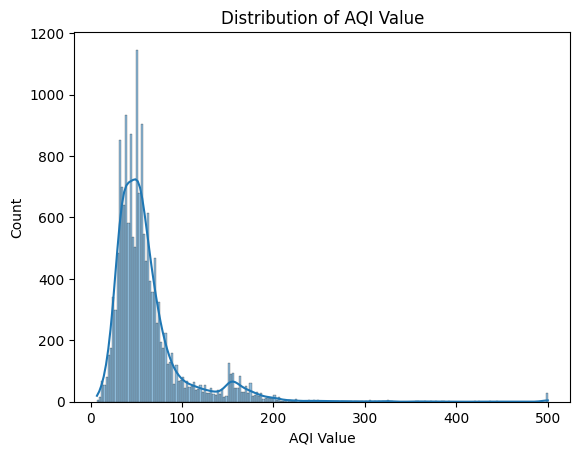

In [ ]:
sns.histplot(data['AQI Value'], kde=True)
plt.title('Distribution of AQI Value')
plt.xlabel('AQI Value')
plt.show()

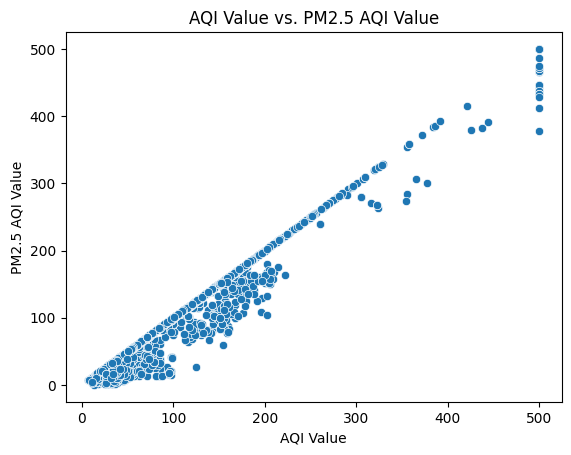

In [ ]:
sns.scatterplot(data=data, x='AQI Value', y='PM2.5 AQI Value')
plt.title('AQI Value vs. PM2.5 AQI Value')
plt.xlabel('AQI Value')
plt.ylabel('PM2.5 AQI Value')
plt.show()

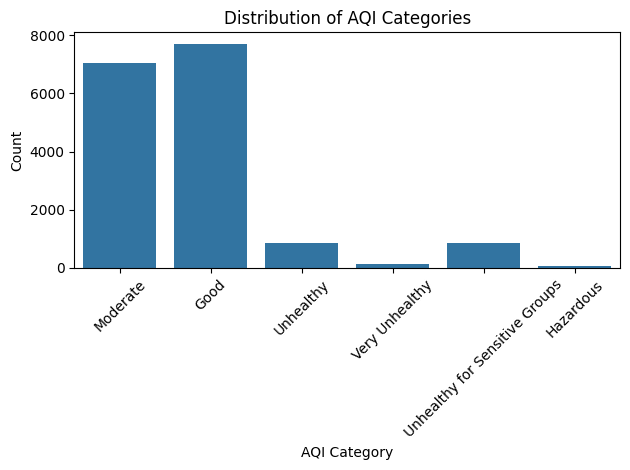

In [ ]:
sns.countplot(data=data, x='AQI Category')
plt.title('Distribution of AQI Categories')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
plt.tight_layout()  # Adjust the plot layout to prevent overlapping
plt.show()

The countplot of AQI Categories by Country provides an overview of the distribution of air quality across different countries. It allows us to see the frequency of each AQI category (Good, Moderate, Unhealthy for Sensitive Groups, etc.) within each country. This information can help us identify countries with higher or lower air quality levels.



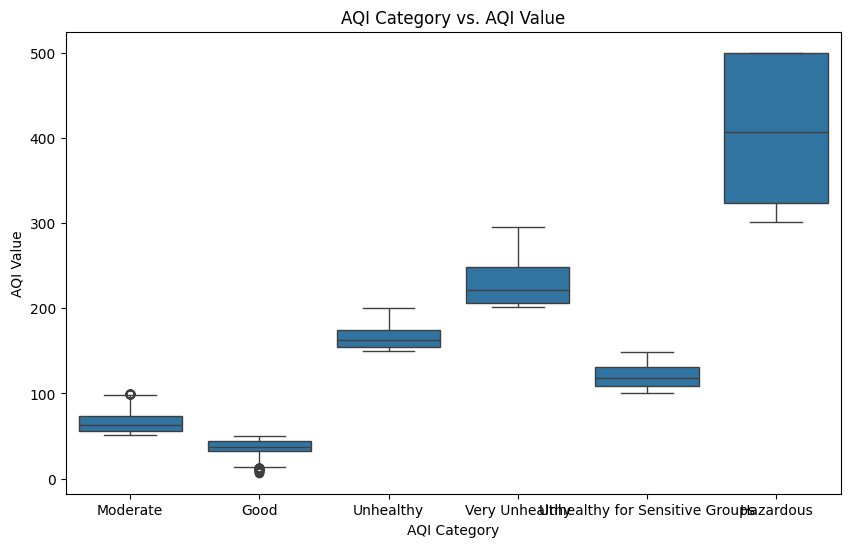

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='AQI Category', y='AQI Value')
plt.title('AQI Category vs. AQI Value')
plt.xlabel('AQI Category')
plt.ylabel('AQI Value')
plt.show()

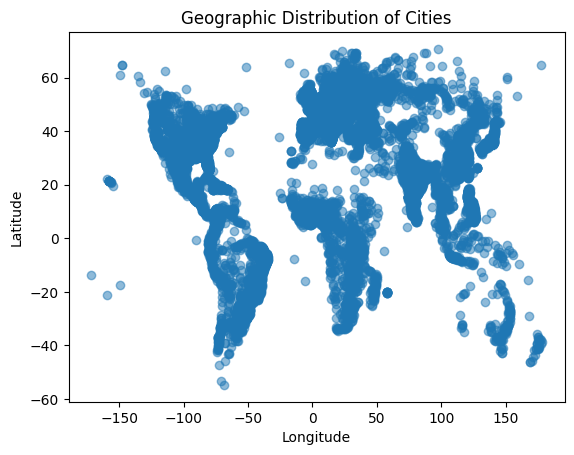

In [ ]:
plt.scatter(data['lng'], data['lat'], alpha=0.5)
plt.title('Geographic Distribution of Cities')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

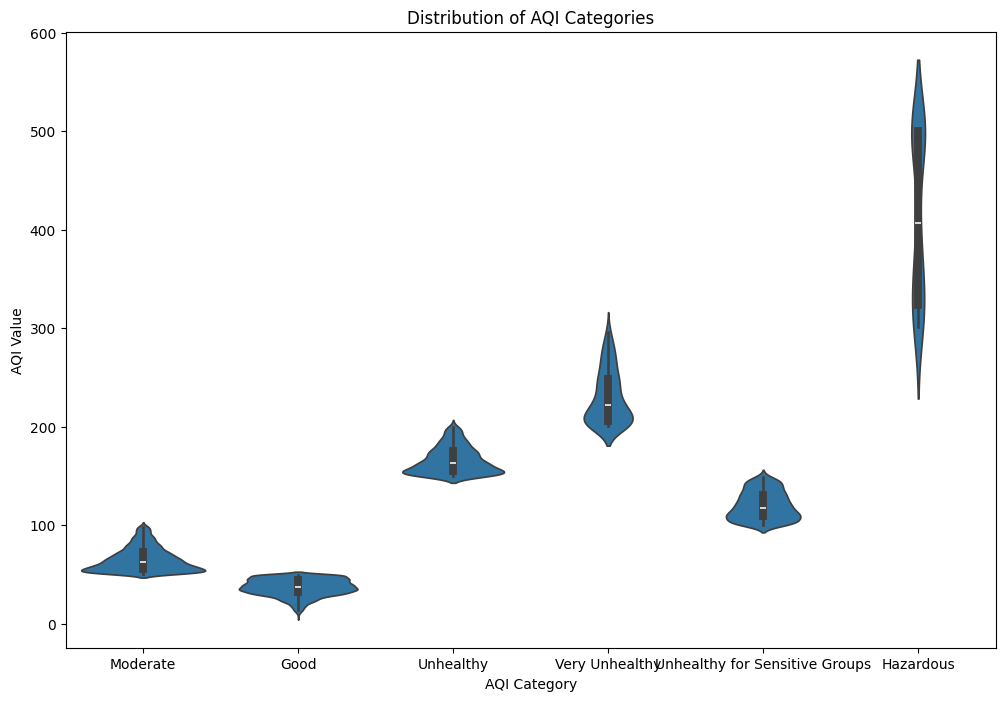

In [ ]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=data, x='AQI Category', y='AQI Value')
plt.title('Distribution of AQI Categories')
plt.xlabel('AQI Category')
plt.ylabel('AQI Value')
plt.show()

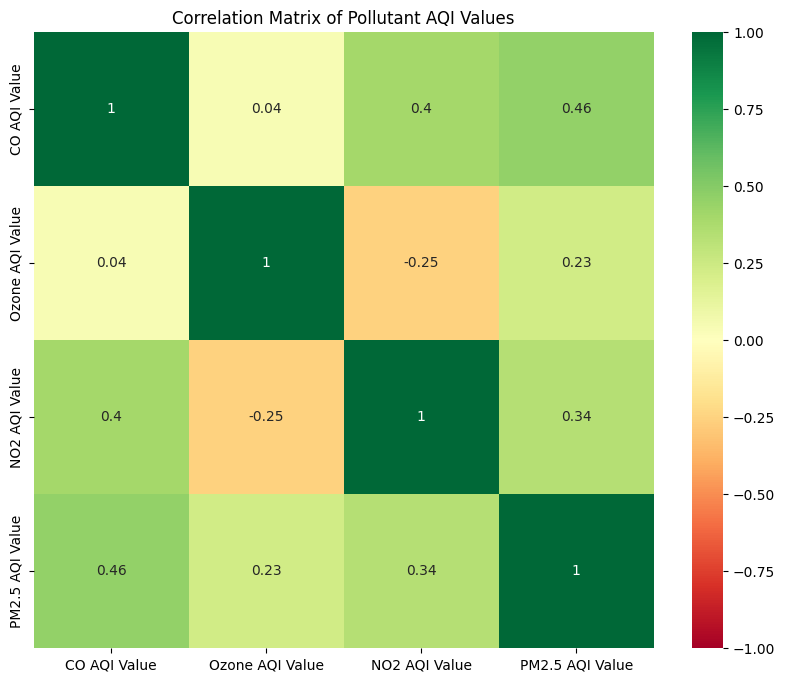

In [ ]:
corr_matrix = data[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Pollutant AQI Values')
plt.show()

In [ ]:
corr_matrix

,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
CO AQI Value,1.000000,0.039752,0.399566,0.458846
Ozone AQI Value,0.039752,1.000000,-0.251169,0.233031
NO2 AQI Value,0.399566,-0.251169,1.000000,0.341455
PM2.5 AQI Value,0.458846,0.233031,0.341455,1.000000


The correlation matrix shows the relationships between AQI values of different pollutants, including CO, Ozone, NO2, and PM2.5. It helps us understand the degree of association between these pollutants and how they contribute to the overall air quality index. The correlation values indicate whether the AQI values of different pollutants tend to increase or decrease together.



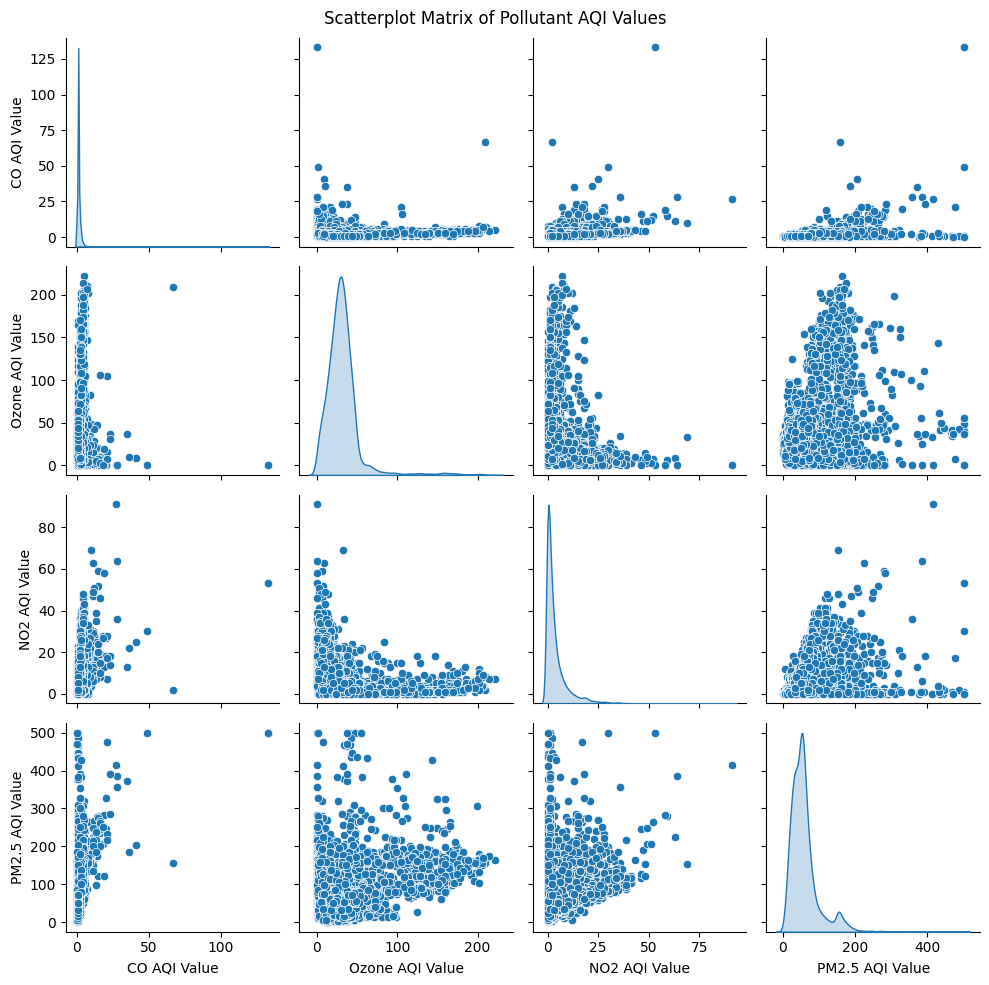

In [ ]:
sns.pairplot(data=data, vars=['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value'], diag_kind='kde')
plt.suptitle('Scatterplot Matrix of Pollutant AQI Values')
plt.tight_layout()
plt.show()

In [ ]:
data.columns


Index(['City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category',
       'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value',
       'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category', 'lat',
       'lng'],
      dtype='object')

In [ ]:
# Calculate the average AQI value for each country
country_avg_aqi = data.groupby('City')['AQI Value'].mean().reset_index()

# Sort the countries based on average AQI value in descending order
top_polluted_countries = country_avg_aqi.sort_values('AQI Value', ascending=False)

# Display the top polluted countries
print(top_polluted_countries.head(10))

               City  AQI Value
3268       Dhanaura      500.0
12911         Tynda      500.0
7436         Malaut      500.0
1587       Boksburg      500.0
8847          Nohar      500.0
7389   Mahendragarh      500.0
4847       Hasanpur      500.0
4844      Harunabad      500.0
9778        Phalodi      500.0
7764           Maur      500.0


Based on the exploratory data analysis (EDA) conducted on the provided air quality dataset, the following conclusions can be drawn:

Overall Air Quality: The majority of the recorded AQI values fall within the "Good" to "Moderate" categories, indicating relatively acceptable air quality in many locations. However, there are also instances of higher AQI values, indicating poorer air quality.

Pollutant Contribution: Among the pollutants measured, PM2.5, NO2, CO, and Ozone are the major contributors to air pollution. These pollutants show varying levels of correlation with each other, suggesting potential interactions and shared sources.

Top Polluted Countries: The analysis highlights the countries with consistently poor air quality based on the recorded AQI values. Identifying these countries can aid in directing resources and interventions to improve air quality in those regions.

Geospatial Analysis: Visualizing the geographic distribution of air quality using latitude and longitude coordinates helps identify areas with higher pollution levels. Certain regions may exhibit clusters of polluted areas, indicating localized sources of pollution.

# **EDA on IRIS-dataset and ML models**

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### **Dataset overview**

The data set consists of 50 samples from each of three species Iris setosa, Iris virginica and Iris versicolor. 4 features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

In [ ]:
from google.colab import files
import io

# Upload the Iris dataset
print("Please download 'Iris.csv' from https://www.kaggle.com/datasets/saurabh00007/iriscsv and upload it below:")
uploaded_iris = files.upload()

# Check if a file was uploaded and read it into a DataFrame
if uploaded_iris:
  for fn_iris in uploaded_iris.keys():
    print(f'User uploaded file "{fn_iris}" with length {len(uploaded_iris[fn_iris])} bytes')
    df = pd.read_csv(io.StringIO(uploaded_iris[fn_iris].decode('utf-8')))
else:
  print("No file was uploaded. Please upload 'Iris.csv'.")

# Display the first few rows of the dataset if it was loaded
if 'df' in locals():
  print("Iris dataset loaded successfully. Displaying first 5 rows:")
  print(df.head())
else:
  print("Iris dataset could not be loaded.")

Please download 'Iris.csv' from https://www.kaggle.com/datasets/saurabh00007/iriscsv and upload it below:


Saving Iris.csv to Iris.csv
User uploaded file "Iris.csv" with length 5107 bytes
Iris dataset loaded successfully. Displaying first 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
#make the Id column as index
df = df.set_index('Id')
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica
149,6.2,3.4,5.4,2.3,Iris-virginica
150,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
#Rename columns
df.rename({'SepalLengthCm': 'sepal_length',
           'SepalWidthCm': 'sepal_width',
           'PetalLengthCm': 'petal_length',
           'PetalWidthCm': 'petal_width',
           'Species': 'species'
          }, inplace=True,axis=1)
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
Id,,,,,
120,6.0,2.2,5.0,1.5,Iris-virginica
136,7.7,3.0,6.1,2.3,Iris-virginica
79,6.0,2.9,4.5,1.5,Iris-versicolor
94,5.0,2.3,3.3,1.0,Iris-versicolor
84,6.0,2.7,5.1,1.6,Iris-versicolor


In [ ]:
#calculate median of each species
x = df.groupby('species').median()
x

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.0,3.4,1.50,0.2
Iris-versicolor,5.9,2.8,4.35,1.3
Iris-virginica,6.5,3.0,5.55,2.0


In [ ]:
#Statistics of this dataset
stats = df.describe()
stats

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
#calculate range, and move columns 25%,50%,75%  and mean values into a dataframe
stats.loc['range'] = stats.loc['max'] - stats.loc['min']
new_df = stats.loc[['mean', 'range', '25%', '50%', '75%']]
new_df.rename({'50%': 'median'}, inplace=True)
new_df

,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
range,3.600000,2.400,5.900000,2.400000
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000


### **Aggregation functions**

In [ ]:
#Calculate mean and median or others using multiple functions at once - 2 methods

df.groupby('species').agg(['mean', 'median'])  # passing a list of recognized strings
df.groupby('species').agg([np.mean, np.median])

sepal_length        sepal_width        petal_length         \
                        mean median        mean median         mean median   
species                                                                      
Iris-setosa            5.006    5.0       3.418    3.4        1.464   1.50   
Iris-versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
Iris-virginica         6.588    6.5       2.974    3.0        5.552   5.55   

                petal_width         
                       mean median  
species                             
Iris-setosa           0.244    0.2  
Iris-versicolor       1.326    1.3  
Iris-virginica        2.026    2.0

In [ ]:
#If we want an explicit aggr function like max for a column
agg_dict={field: ['mean', 'median'] for  field in df.columns.tolist() if field != 'species'}
agg_dict['petal_length'] = 'max'
df.groupby('species').agg(agg_dict)

sepal_length        sepal_width        petal_length  \
                        mean median        mean median          max   
species                                                               
Iris-setosa            5.006    5.0       3.418    3.4          1.9   
Iris-versicolor        5.936    5.9       2.770    2.8          5.1   
Iris-virginica         6.588    6.5       2.974    3.0          6.9   

                petal_width         
                       mean median  
species                             
Iris-setosa           0.244    0.2  
Iris-versicolor       1.326    1.3  
Iris-virginica        2.026    2.0

### **Visualisations**

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### **Distribution Plot**

Text(0.5, 1.0, 'Distribution of petal-width')

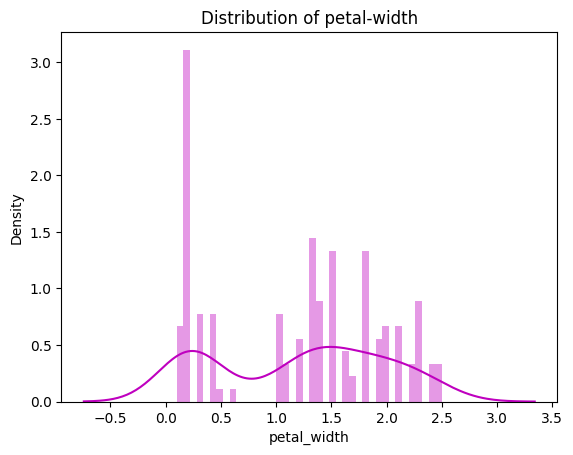

In [ ]:
sns.distplot(a=df['petal_width'], bins=40, color='m')
plt.title('Distribution of petal-width')

### **Count plot**

displays the number of observations for a categorical variable using bars.

<Axes: xlabel='species', ylabel='count'>

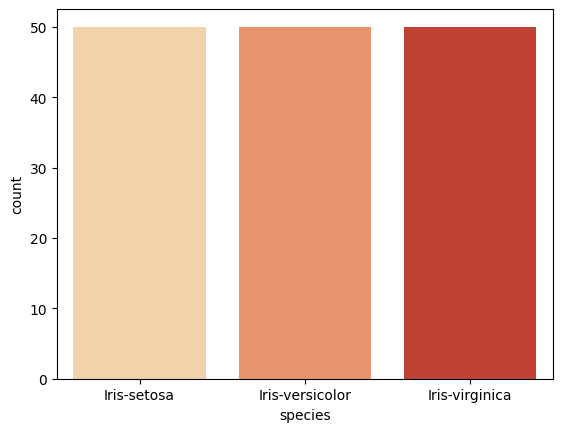

In [ ]:
sns.countplot(x='species',data=df, palette="OrRd")


### **Box Plot**

shows the distribution of quantitative data across a categorical variable.

<Axes: xlabel='species', ylabel='sepal_width'>

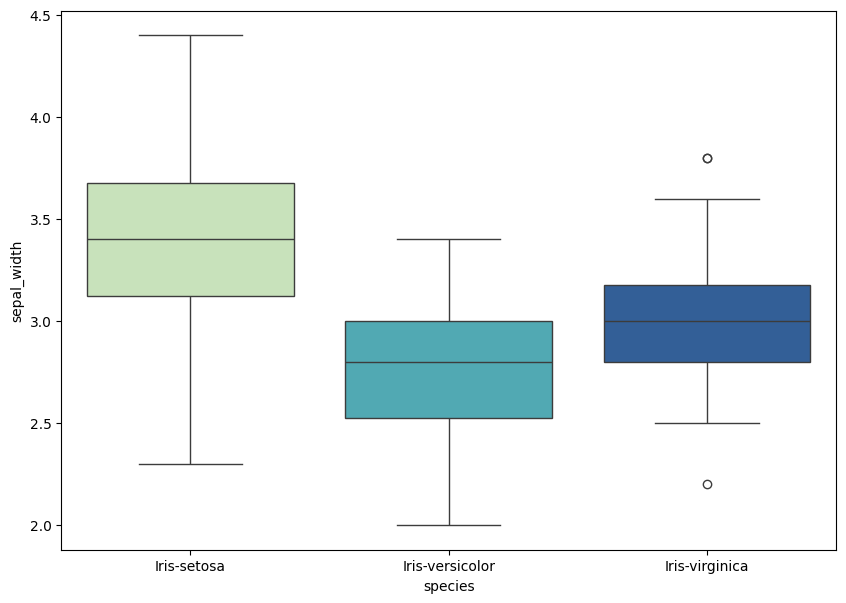

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(x='species',y='sepal_width',data=df ,palette='YlGnBu')

### **violin plot**

This is a variation of box plot. It shows the distribution of quantitative data across several levels of categorical variables. The violin plot also features a kde of the underlying distribution

<Axes: xlabel='species', ylabel='petal_length'>

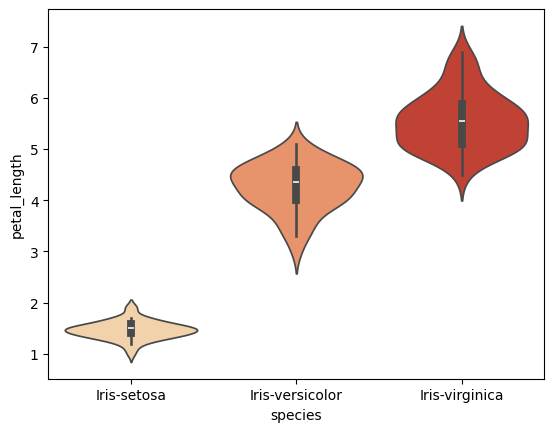

In [ ]:
sns.violinplot(x='species', y='petal_length', data=df, palette='OrRd')


### **Matrix plots**

HeatMap - It provides the graph of the correlation matrix.
Cluster Map - It is a plot of matrix dataset as a hierarchically clustered heatmap.

<Axes: >

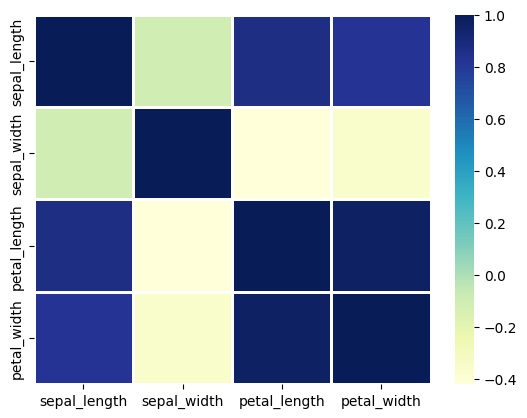

In [ ]:
sns.heatmap(df.drop('species', axis=1).corr(), cmap="YlGnBu", linecolor='white', linewidths=1)

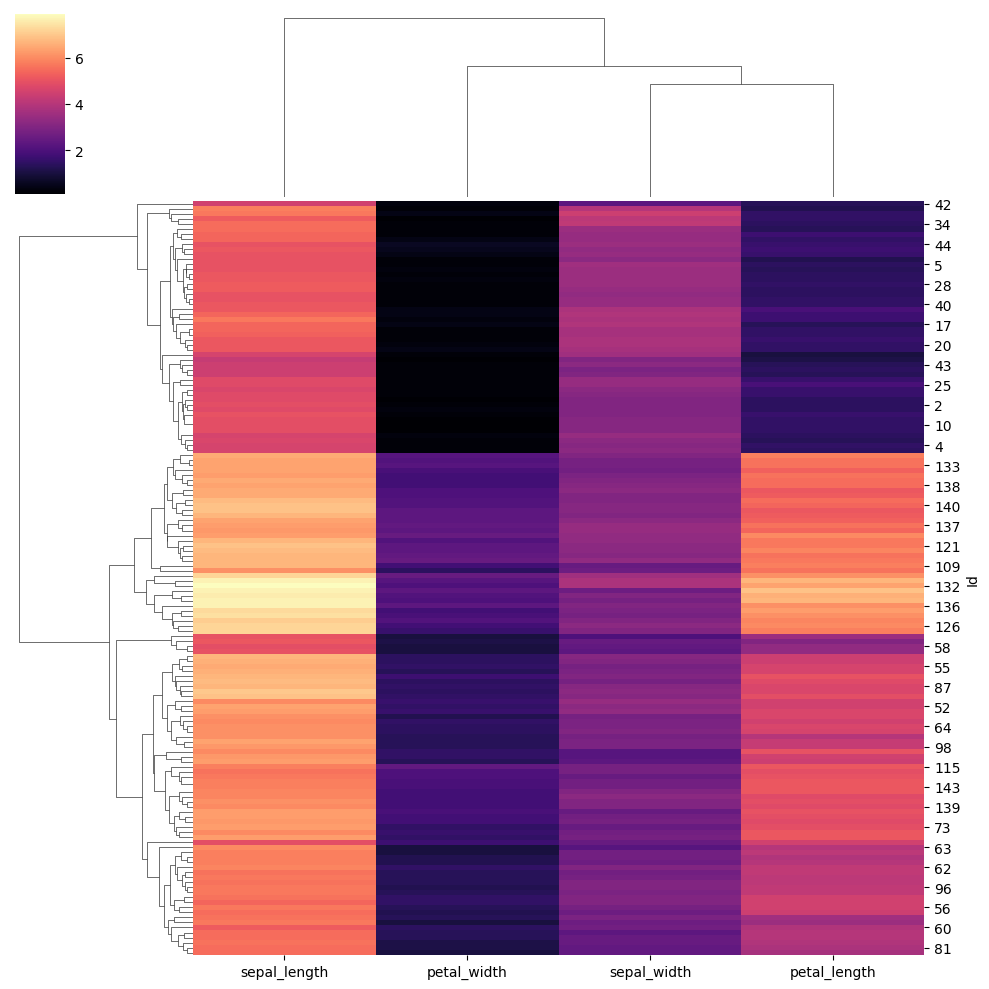

In [ ]:
#Cluster map takes only quantitative variables, so we need to do some processing here.
x = df.drop('species',axis=1)
g = sns.clustermap(x, cmap="magma")

### **Regression Plots**

<Axes: xlabel='petal_width', ylabel='petal_length'>

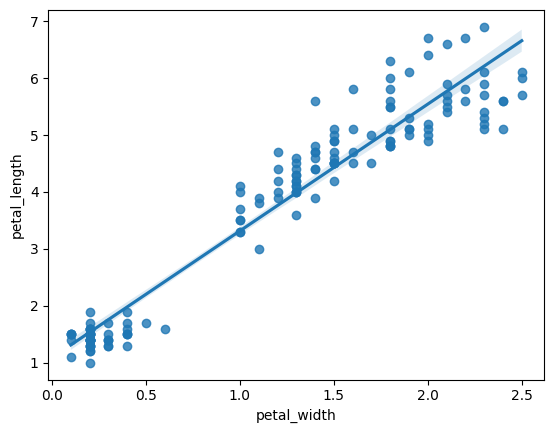

In [ ]:
sns.regplot(x='petal_width', y='petal_length', data=df)


**Axis Grids - These are graphs that combine various plots using FacetGrid to realize complex visualizations.**

**LM Plots**

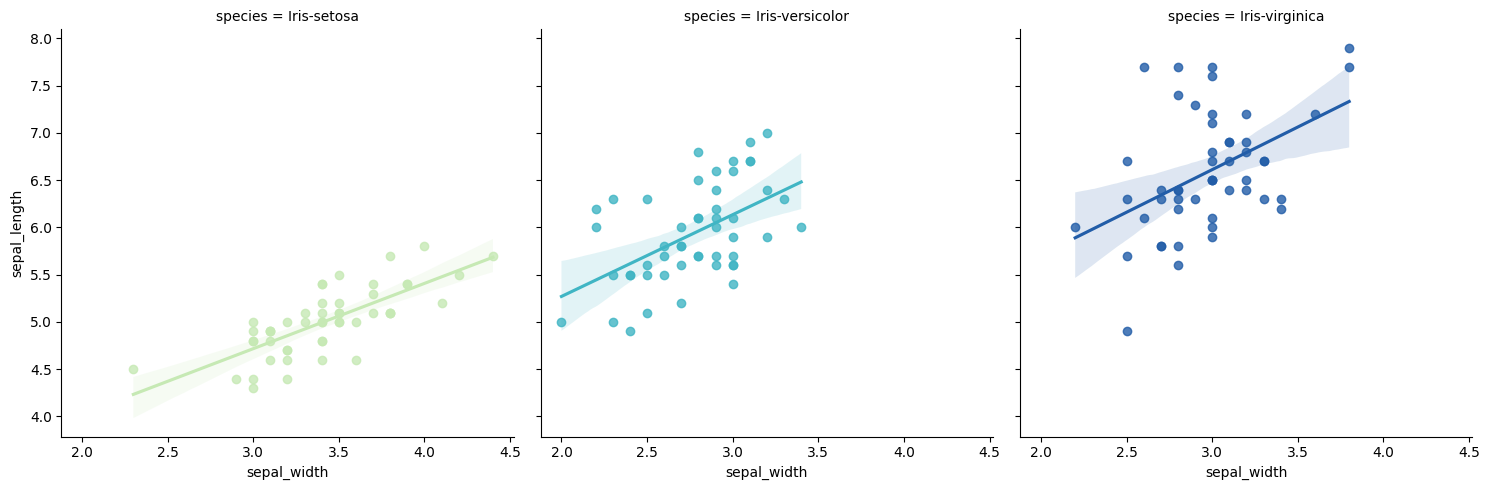

In [ ]:
sns.lmplot(x = 'sepal_width', y = 'sepal_length', data = df, col = 'species', hue = 'species', palette = 'YlGnBu')

### **Joint Plot**

Used to draw a plot of two variables with bivariate and univariate graphs.

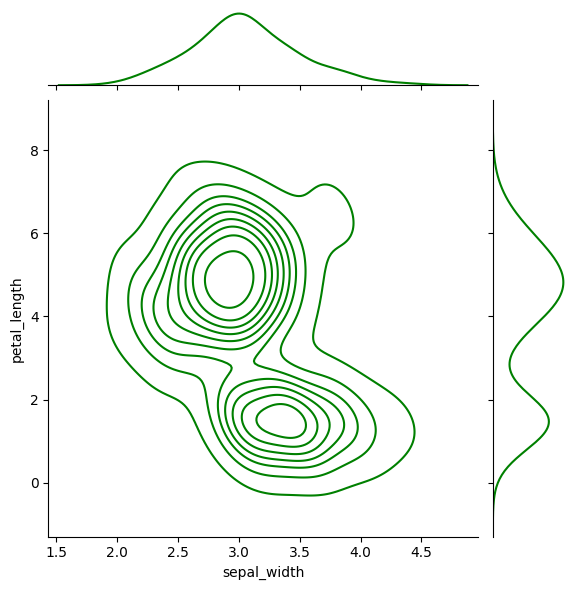

In [ ]:
sns.jointplot(x="sepal_width", y="petal_length", data=df, kind="kde", color="g")


### **Scatterplot**

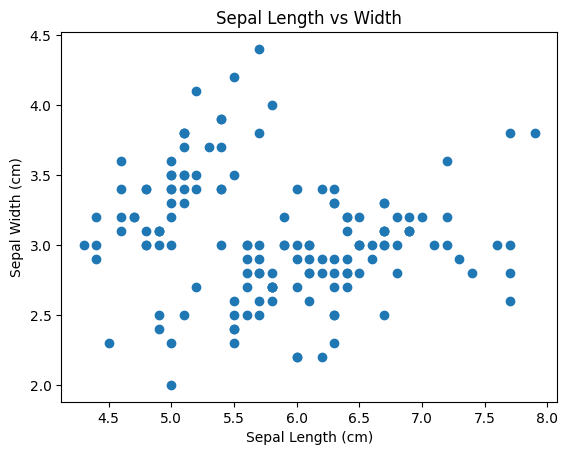

In [ ]:
ax = plt.axes()

ax.scatter(df.sepal_length, df.sepal_width)

# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');

### **Histograms**

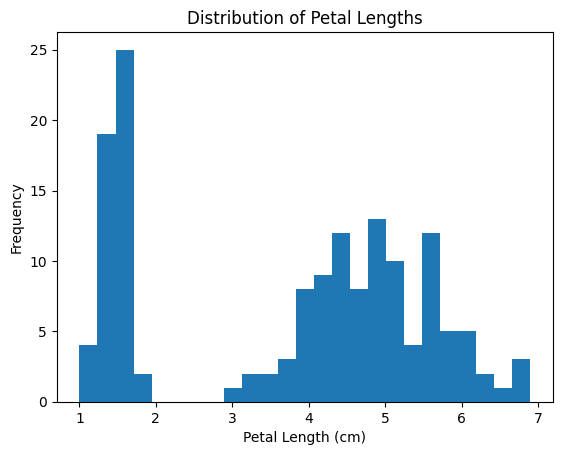

In [ ]:
ax = plt.axes()
ax.hist(df.petal_length, bins=25);

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

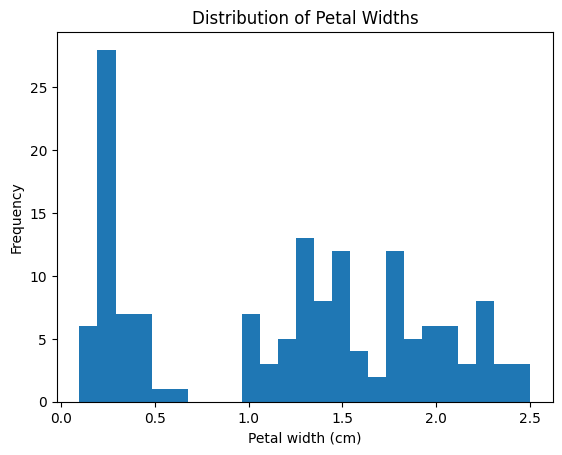

In [ ]:
ax = plt.axes()
ax.hist(df.petal_width, bins=25);

ax.set(xlabel='Petal width (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Widths');

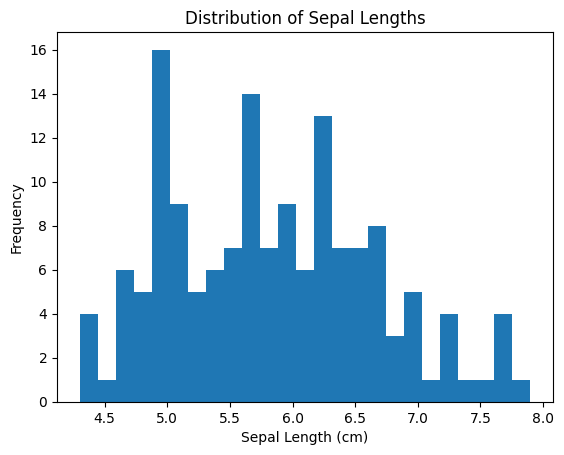

In [ ]:
ax = plt.axes()
ax.hist(df.sepal_length, bins=25);

ax.set(xlabel='Sepal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Sepal Lengths');

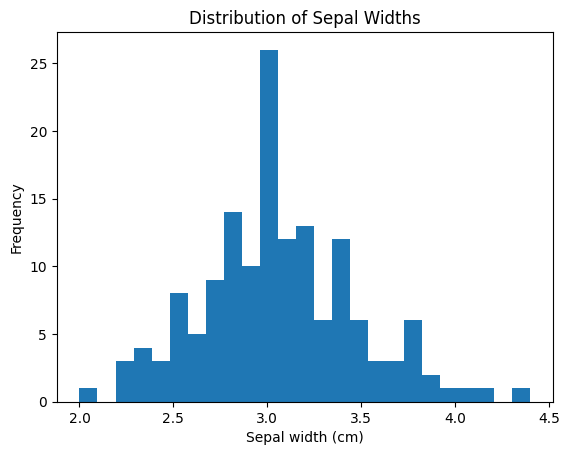

In [ ]:
ax = plt.axes()
ax.hist(df.sepal_width, bins=25);

ax.set(xlabel='Sepal width (cm)',
       ylabel='Frequency',
       title='Distribution of Sepal Widths');

**TAKE-AWAY From the histograms, we observe that Petal length and petal width are influencing variables for the different species**

**plot histogram using pandas**

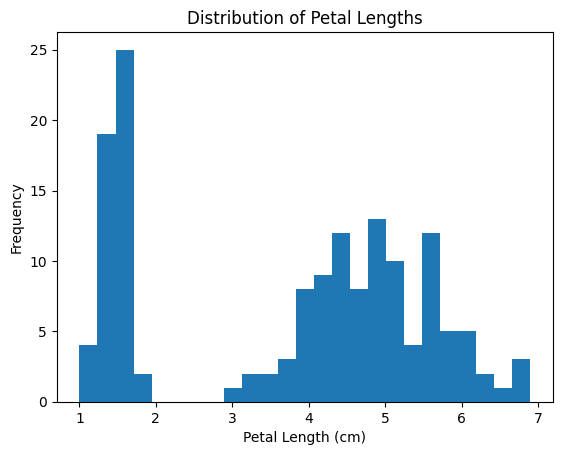

In [ ]:
ax = df.petal_length.plot.hist(bins=25)

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

### **plotting all histograms**

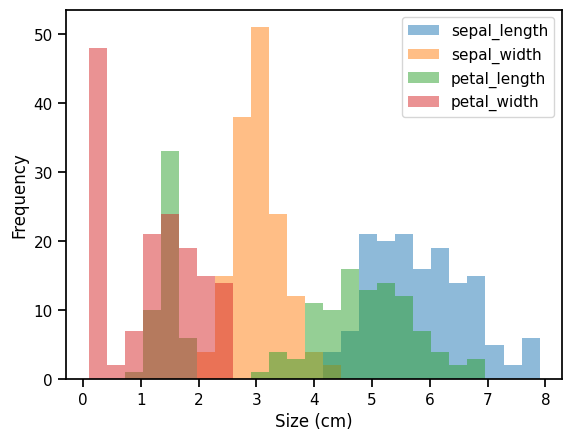

In [ ]:
import seaborn as sns
sns.set_context('notebook')


ax = df.plot.hist(bins=25, alpha=0.5)
ax.set_xlabel('Size (cm)');

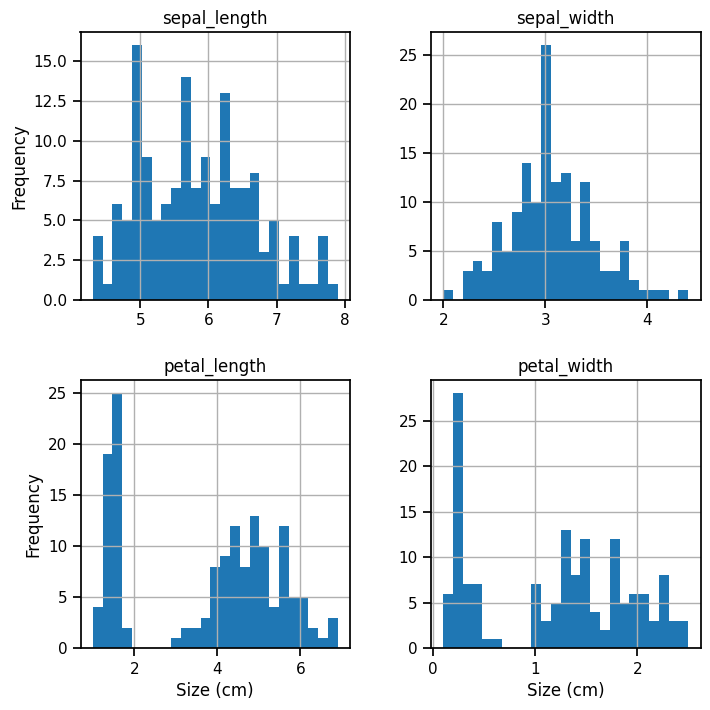

In [ ]:
axList = df.hist(bins=25, figsize=(8,8))

# Get the number of rows and columns in the subplot grid
rows, cols = axList.shape

# Add some x- and y- labels to first column and last row
for i in range(rows):
    for j in range(cols):
        ax = axList[i, j]
        if i == rows - 1:  # Check if it's the last row
            ax.set_xlabel('Size (cm)')
        if j == 0:  # Check if it's the first column
            ax.set_ylabel('Frequency')

**all features in single boxplot**

In [ ]:
# First we have to reshape the data so there is
# only a single measurement in each column

plot_data = (df
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()

,species,measurement,size
0,Iris-setosa,sepal_length,5.1
1,Iris-setosa,sepal_width,3.5
2,Iris-setosa,petal_length,1.4
3,Iris-setosa,petal_width,0.2
4,Iris-setosa,sepal_length,4.9


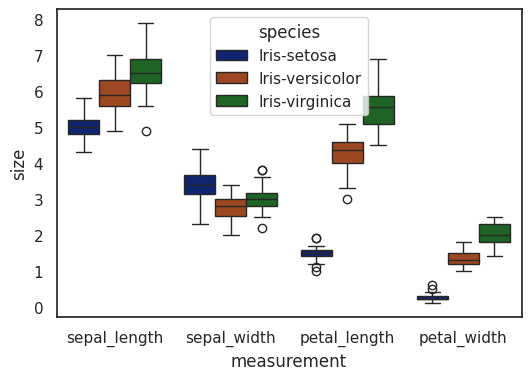

In [ ]:
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size',
            hue='species', data=plot_data);

### **Pairplot to examine the correlations**

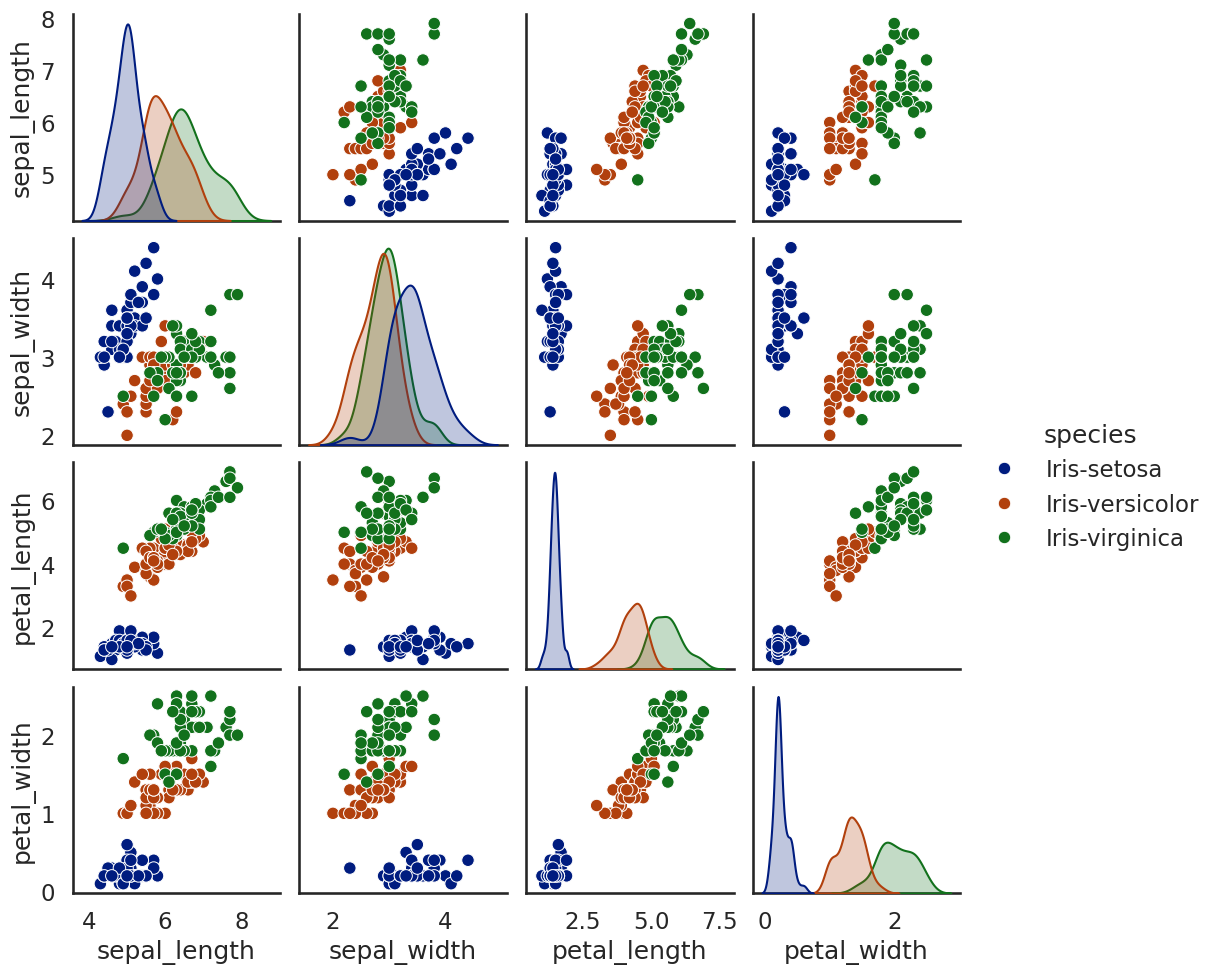

In [ ]:
sns.set_context('talk')
sns.pairplot(df, hue='species');


In [ ]:
from sklearn import datasets
from sklearn.cluster import KMeans
#load the data
iris = datasets.load_iris()

print(iris.data)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [ ]:
#Iris data Ground Truth result
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [ ]:
print(iris.DESCR)


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

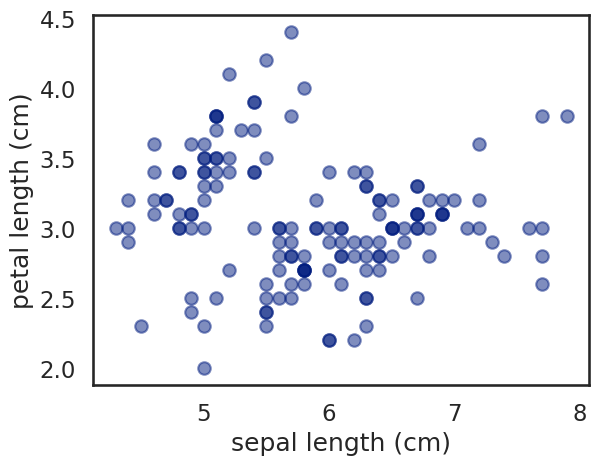

In [ ]:
samples = iris.data
x = samples[:,0]
y = samples[:,1]

sepal_length_width = np.array(list(zip(x, y)))
plt.scatter(x, y, alpha=0.5)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')

plt.show()

### **Clustering using k-means from scikit-learn library**

In [ ]:
k=3
model = KMeans(n_clusters = k)

In [ ]:
#use .fit() method to fit the model to the samples
model.fit(samples)

KMeans(n_clusters=3)

In [ ]:
# Use .predict() to determine the labels of samples
labels = model.predict(samples)
# Print the labels
print(labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 1 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]


### **Train-test splits**

In [ ]:
data = df.copy()
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
from sklearn.model_selection import train_test_split

target = 'species'
X = data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 11)
# it shows 80% of data is split for training and 20% of the data goes to testing.
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Test Accuracy for Scikit-Learn model:', metrics.accuracy_score(y_test, y_pred)* 100,'%')

Test Accuracy for Scikit-Learn model: 93.33333333333333 %


### **Evaluation Metrics**
Jaccard-index
Confusion matrix
Logloss
F1-Score

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.82      0.90        11

       accuracy                           0.93        30
      macro avg       0.94      0.94      0.94        30
   weighted avg       0.94      0.93      0.93        30



**Questions**

**1. Describe all three data set in terms of following : how many features, their categories (num,text,categorical, nominal,ordinal etc), number of tuples, missing values.**

**Extract and Consolidate AQI Data Information:** Extract relevant information about the World Air Quality Index dataset (number of features, feature categories, number of tuples, and missing values) from the outputs of data.info(), data.describe(include='all'), and data.isnull().sum().

**Extract and Consolidate Iris DataFrame Information:** Extract relevant information about the Iris dataset loaded into a pandas DataFrame (df) (number of features, feature categories, number of tuples, and missing values) from the outputs of df.info(), df.describe(), and df.isnull().sum().

**Extract and Consolidate Scikit-learn Iris Information:** Extract relevant information about the Iris dataset loaded directly from sklearn.datasets (iris) (number of features, feature categories, number of tuples, and missing values) from the outputs of iris.data.shape and iris.DESCR.

**Present Dataset Descriptions:** Consolidate and present the descriptions of all three datasets in a clear, structured format, detailing the number of features, their categories (numerical, categorical), the number of tuples, and any missing values.

**2. In IRIS data set which non graphical EDA is performed ?**

The following non-graphical EDA steps were performed on the Iris dataset:

**Displaying data:** df.tail() and df.sample(5) were used to view the last few rows and a random sample of rows, respectively.

**Descriptive Statistics:** df.describe() was used to generate summary statistics (count, mean, std, min, max, quartiles) for numerical columns.

**Column Renaming:** Columns were renamed for better readability using df.rename().
Median Calculation: The median of each feature grouped by species was calculated using df.groupby('species').median().

**Range Calculation:** The range (max - min) for each numerical feature was calculated and added to the descriptive statistics.

**Advanced Aggregation:** Multiple aggregation functions (mean, median, max) were applied to different columns grouped by species using df.groupby('species').agg().

**3.  In  Air Quality data set which graph is used to perform multivariate analysis?**

In the Air Quality dataset, the following graphs were used to perform multivariate analysis:

**Correlation Matrix Heatmap (BcETo-66Eb8a):**
 This heatmap visualizes the correlations between multiple pollutant AQI values (CO AQI Value, Ozone AQI Value, NO2 AQI Value, PM2.5 AQI Value). It shows the pairwise relationships and their strengths simultaneously.

 **Pairplot (rEbYIJgAElQo):** This generates a scatterplot matrix for all specified numerical variables (CO AQI Value, Ozone AQI Value, NO2 AQI Value, PM2.5 AQI Value), along with univariate distributions (KDE plots) on the diagonals. This is a comprehensive way to visualize pairwise relationships and individual distributions in a multivariate context.

 **4. In Wine quality data set can you do non graphical EDA ? Explain your answer.**


In [ ]:
import pandas as pd

# Load the wine quality dataset
wine_df = pd.read_csv('/content/winequality-white.csv', sep=';')

print("First 5 rows of the Wine Quality dataset:")
display(wine_df.head())

First 5 rows of the Wine Quality dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Non-Graphical EDA on Wine Quality Dataset

**1. Displaying basic information and data types:**

In [ ]:
print(wine_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None


**2. Descriptive Statistics:**

In [ ]:
display(wine_df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


**3. Checking for missing values:**

In [ ]:
print(wine_df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


From these non-graphical EDA steps on the Wine Quality dataset, we can observe the following:

*   **Data Types and Non-Null Counts**: The `wine_df.info()` output shows that all columns are numerical (float64 or int64) and have 4898 non-null entries, indicating no missing values in any of the columns initially. This simplifies the data cleaning process as no imputation or dropping of rows/columns due to missing values is required.
*   **Descriptive Statistics**: The `wine_df.describe()` output provides key statistical measures like mean, standard deviation, min, max, and quartiles for each feature. This gives insights into the distribution and range of values for each chemical property and the quality score. For instance, 'pH' has a relatively narrow range, while 'total sulfur dioxide' and 'alcohol' have broader distributions.
*   **Missing Values**: The `wine_df.isnull().sum()` confirms that there are no missing values in any column, which is ideal for direct analysis.